# 딥러닝 실습 - 퍼셉트론에서 MLP까지


## 학습 목표

1. **생물학적 뉴런**과 **인공 뉴런**의 관계를 이해함
2. **퍼셉트론**으로 논리 게이트(AND, OR, NOT)를 구현함
3. **XOR 문제**와 단일 퍼셉트론의 한계를 파악함
4. **다층 퍼셉트론(MLP)**의 등장 배경과 구조를 이해함
5. **순전파**와 **역전파**의 개념을 직관적으로 이해함

### 1.1 생물학적 뉴런 vs 인공 뉴런

| 생물학적 뉴런 | 인공 뉴런 | 역할 |
|:---:|:---:|:---|
| 수상돌기 (Dendrites) | 입력 $x_i$ | 외부에서 정보 수신 |
| 시냅스 강도 | 가중치 $w_i$ | 연결의 중요도 결정 |
| 세포체 (Soma) | 가중합 $\sum$ | 입력 정보 통합 |
| 역치 (Threshold) | 편향 $b$ | 발화 기준 설정 |
| 활동 전위 발생 | 활성화 함수 $f$ | 출력 여부 결정 |
| 축삭 출력 | 출력 $y$ | 다음 단계로 신호 전달 |

### 1.2 퍼셉트론의 수학적 정의

1958년 **프랭크 로젠블랫(Frank Rosenblatt)** 이 생물학적 뉴런을 수학적으로 모델링하여 **퍼셉트론(Perceptron)** 을 발명

#### 퍼셉트론 연산 과정

**Step 1: 가중합 계산**

$$z = \sum_{i=1}^{n} w_i x_i + b = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b$$

**Step 2: 활성화 함수 적용**

$$y = f(z)$$

여기서:
- $x_i$: 입력값 (features)
- $w_i$: 가중치 (각 입력의 중요도)
- $b$: 편향 (bias, 발화 기준 조절)
- $f$: 활성화 함수
- $y$: 출력값

#### 계단 함수 (Step Function)

초기 퍼셉트론에서 사용한 가장 단순한 활성화 함수:

$$f(z) = \begin{cases} 1 & \text{if } z > 0 \\ 0 & \text{if } z \leq 0 \end{cases}$$

**의미**: 가중합이 0보다 크면 "발화" (출력 1), 아니면 "비활성" (출력 0)

In [2]:
# 필요 라이브러리 임포트 및 한글 폰트 설정
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Google Colab 및 로컬 환경 호환)
import matplotlib.font_manager as fm

def setup_korean_font():
    """한글 폰트를 설정하는 함수"""
    # 사용 가능한 한글 폰트 목록
    korean_fonts = ['NanumGothic', 'NanumBarunGothic', 'Malgun Gothic', 
                    'AppleGothic', 'DejaVu Sans']
    
    # 시스템에서 사용 가능한 폰트 찾기
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    
    for font in korean_fonts:
        if font in available_fonts:
            plt.rcParams['font.family'] = font
            plt.rcParams['axes.unicode_minus'] = False
            print(f"한글 폰트 설정 완료: {font}")
            return
    
    # 폰트를 찾지 못한 경우 Colab용 설치 시도
    try:
        import subprocess
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], 
                      capture_output=True, check=True)
        fm._rebuild()
        plt.rcParams['font.family'] = 'NanumGothic'
        plt.rcParams['axes.unicode_minus'] = False
        print("나눔고딕 폰트 설치 및 설정 완료")
    except:
        print("한글 폰트 설정 실패 - 영문으로 표시됩니다.")


# 시각화 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')

setup_korean_font()

print("라이브러리 및 설정 완료")

한글 폰트 설정 완료: NanumGothic
라이브러리 및 설정 완료


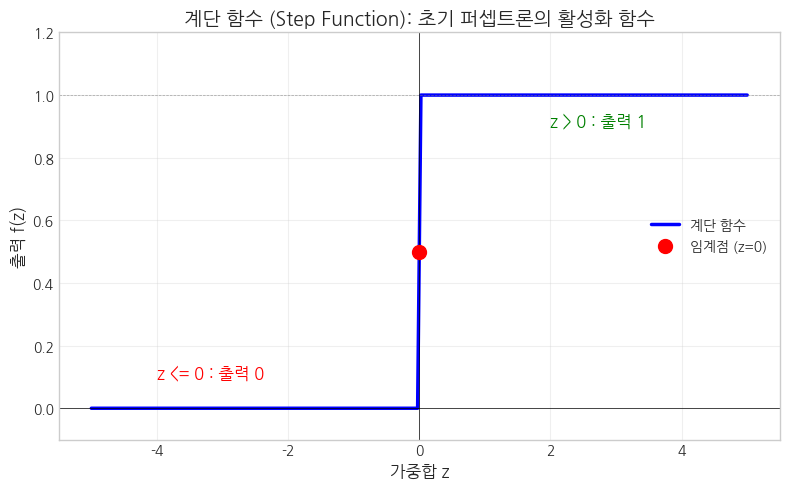


계단 함수의 특성:
- 출력이 0 또는 1로 이산적 (discrete)
- 미분 불가능 (z=0에서 불연속)
- 현대 딥러닝에서는 시그모이드, ReLU 등으로 대체됨


In [3]:
def step_function(z):
    """
    계단 함수 (Step Function)
    
    수학적 정의:
        f(z) = 1  if z > 0
        f(z) = 0  if z <= 0
    
    Parameters:
        z: 가중합 (스칼라 또는 배열)
    
    Returns:
        활성화 출력 (0 또는 1)
    """
    return np.where(z > 0, 1, 0)

# 계단 함수 시각화
z = np.linspace(-5, 5, 200)
y = step_function(z)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(z, y, 'b-', linewidth=2.5, label='계단 함수')
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax.axhline(y=1, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5)

# 임계점 표시
ax.scatter([0], [0.5], color='red', s=100, zorder=5, label='임계점 (z=0)')
ax.annotate('z > 0 : 출력 1', xy=(2, 0.9), fontsize=12, color='green')
ax.annotate('z <= 0 : 출력 0', xy=(-4, 0.1), fontsize=12, color='red')

ax.set_xlabel('가중합 z', fontsize=12)
ax.set_ylabel('출력 f(z)', fontsize=12)
ax.set_title('계단 함수 (Step Function): 초기 퍼셉트론의 활성화 함수', fontsize=14)
ax.legend(loc='center right')
ax.set_ylim(-0.1, 1.2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n계단 함수의 특성:")
print("- 출력이 0 또는 1로 이산적 (discrete)")
print("- 미분 불가능 (z=0에서 불연속)")
print("- 현대 딥러닝에서는 시그모이드, ReLU 등으로 대체됨")

---

## 실습1 2: 퍼셉트론으로 논리 게이트 구현하기

### 2.1 논리 게이트란?

디지털 회로의 기본 구성 요소로, 입력에 따라 특정 논리 연산을 수행함.

| 게이트 | 의미 | 실생활 예시 |
|:---:|:---|:---|
| AND | 둘 다 참이면 참 | 비밀번호 **그리고** 지문이 일치해야 잠금 해제 |
| OR | 하나라도 참이면 참 | 화재경보 **또는** 침입경보가 울리면 대피 |
| NOT | 반전 | 스위치가 꺼져있으면 켜기 |
| NAND | AND의 부정 | 범용 게이트 (모든 논리 구현 가능) |

In [4]:
def AND_gate(x1, x2):
    """
    AND 게이트 퍼셉트론
    
    논리: x1 AND x2 - 둘 다 1이어야 출력 1
    
    수학적 표현:
        z = w1*x1 + w2*x2 + b = 0.5*x1 + 0.5*x2 - 0.7
        결정 경계: x1 + x2 = 1.4
    
    진리표:
        (0,0) -> 0.5*0 + 0.5*0 - 0.7 = -0.7 < 0 -> 0
        (0,1) -> 0.5*0 + 0.5*1 - 0.7 = -0.2 < 0 -> 0
        (1,0) -> 0.5*1 + 0.5*0 - 0.7 = -0.2 < 0 -> 0
        (1,1) -> 0.5*1 + 0.5*1 - 0.7 = 0.3 > 0 -> 1
    """
    w1, w2 = 0.5, 0.5
    b = -0.7
    z = w1 * x1 + w2 * x2 + b
    return step_function(z)


def OR_gate(x1, x2):
    """
    OR 게이트 퍼셉트론
    
    논리: x1 OR x2 - 하나라도 1이면 출력 1
    
    수학적 표현:
        z = 0.5*x1 + 0.5*x2 - 0.2
        결정 경계: x1 + x2 = 0.4
    """
    w1, w2 = 0.5, 0.5
    b = -0.2
    z = w1 * x1 + w2 * x2 + b
    return step_function(z)


def NAND_gate(x1, x2):
    """
    NAND 게이트 퍼셉트론 (NOT AND)
    
    논리: NOT(x1 AND x2) - 둘 다 1일 때만 출력 0
    
    수학적 표현:
        z = -0.5*x1 - 0.5*x2 + 0.7
        음수 가중치로 AND를 반전
    """
    w1, w2 = -0.5, -0.5
    b = 0.7
    z = w1 * x1 + w2 * x2 + b
    return step_function(z)


def NOT_gate(x):
    """
    NOT 게이트 퍼셉트론
    
    논리: NOT x - 입력 반전
    
    수학적 표현:
        z = -1.0*x + 0.5
    """
    w = -1.0
    b = 0.5
    z = w * x + b
    return step_function(z)

In [5]:
# 논리 게이트 진리표 출력
print("=" * 60)
print("퍼셉트론으로 구현한 논리 게이트 진리표")
print("=" * 60)

print("\n[AND 게이트] - 둘 다 1이어야 1")
print("-" * 40)
print(f"{'x1':^6} {'x2':^6} {'AND':^8} {'z 계산':^20}")
print("-" * 40)
for x1 in [0, 1]:
    for x2 in [0, 1]:
        z = 0.5*x1 + 0.5*x2 - 0.7
        result = AND_gate(x1, x2)
        print(f"{x1:^6} {x2:^6} {result:^8} {f'0.5*{x1}+0.5*{x2}-0.7={z:.1f}':^20}")

print("\n[OR 게이트] - 하나라도 1이면 1")
print("-" * 40)
print(f"{'x1':^6} {'x2':^6} {'OR':^8}")
print("-" * 40)
for x1 in [0, 1]:
    for x2 in [0, 1]:
        print(f"{x1:^6} {x2:^6} {OR_gate(x1, x2):^8}")

print("\n[NAND 게이트] - AND의 반대")
print("-" * 40)
print(f"{'x1':^6} {'x2':^6} {'NAND':^8}")
print("-" * 40)
for x1 in [0, 1]:
    for x2 in [0, 1]:
        print(f"{x1:^6} {x2:^6} {NAND_gate(x1, x2):^8}")

퍼셉트론으로 구현한 논리 게이트 진리표

[AND 게이트] - 둘 다 1이어야 1
----------------------------------------
  x1     x2     AND            z 계산        
----------------------------------------
  0      0       0     0.5*0+0.5*0-0.7=-0.7
  0      1       0     0.5*0+0.5*1-0.7=-0.2
  1      0       0     0.5*1+0.5*0-0.7=-0.2
  1      1       1     0.5*1+0.5*1-0.7=0.3 

[OR 게이트] - 하나라도 1이면 1
----------------------------------------
  x1     x2      OR   
----------------------------------------
  0      0       0    
  0      1       1    
  1      0       1    
  1      1       1    

[NAND 게이트] - AND의 반대
----------------------------------------
  x1     x2     NAND  
----------------------------------------
  0      0       1    
  0      1       1    
  1      0       1    
  1      1       0    


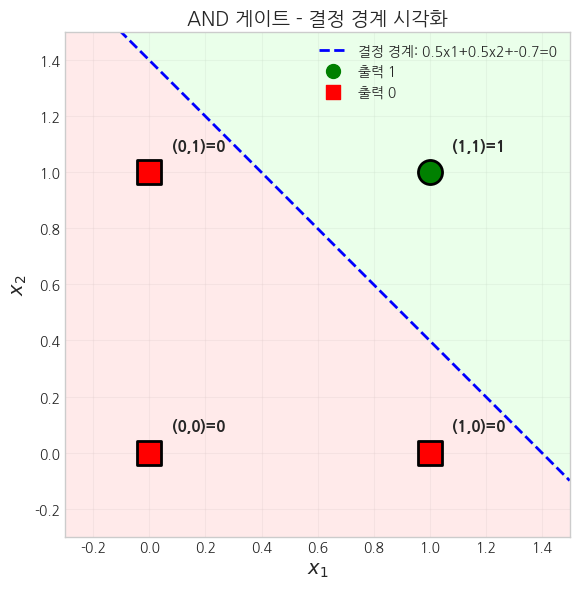

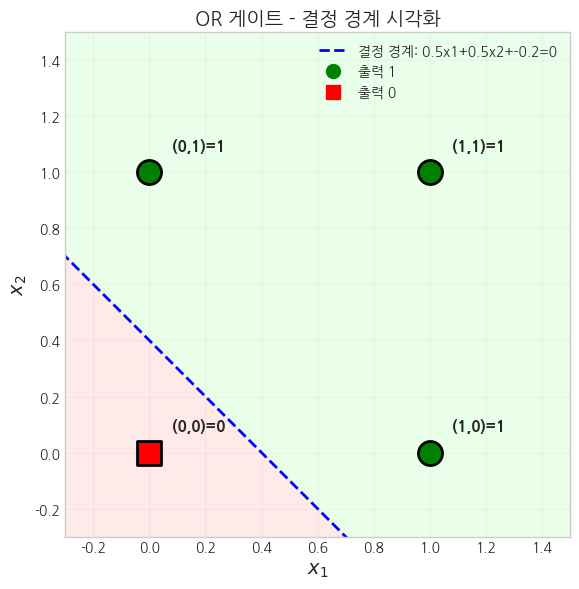


핵심 관찰:
- AND, OR 게이트는 모두 직선 하나로 0과 1을 분리 가능
- 이를 '선형 분리 가능(Linearly Separable)'이라고 함
- 퍼셉트론은 선형 분리 가능한 문제만 해결할 수 있음


In [6]:
def visualize_gate(gate_func, gate_name, w1, w2, b):
    """
    논리 게이트의 결정 경계를 시각화
    
    결정 경계: w1*x1 + w2*x2 + b = 0
    -> x2 = -(w1*x1 + b) / w2
    """
    fig, ax = plt.subplots(figsize=(7, 6))
    
    # 결정 영역 색상
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200),
                         np.linspace(-0.5, 1.5, 200))
    Z = np.array([[gate_func(x, y) for x, y in zip(row_x, row_y)]
                  for row_x, row_y in zip(xx, yy)])
    ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5],
                colors=['#ffcccc', '#ccffcc'], alpha=0.4)
    
    # 결정 경계선
    if w2 != 0:
        x_line = np.linspace(-0.5, 1.5, 100)
        y_line = -(w1 * x_line + b) / w2
        ax.plot(x_line, y_line, 'b--', linewidth=2, 
                label=f'결정 경계: {w1}x1+{w2}x2+{b}=0')
    
    # 데이터 포인트
    points = [(0, 0), (0, 1), (1, 0), (1, 1)]
    for x1, x2 in points:
        result = gate_func(x1, x2)
        color = 'green' if result == 1 else 'red'
        marker = 'o' if result == 1 else 's'
        ax.scatter(x1, x2, c=color, s=300, marker=marker,
                   edgecolor='black', linewidth=2, zorder=5)
        label = f'({x1},{x2})={result}'
        ax.annotate(label, (x1+0.08, x2+0.08), fontsize=11, fontweight='bold')
    
    ax.set_xlim(-0.3, 1.5)
    ax.set_ylim(-0.3, 1.5)
    ax.set_xlabel('$x_1$', fontsize=14)
    ax.set_ylabel('$x_2$', fontsize=14)
    ax.set_title(f'{gate_name} 게이트 - 결정 경계 시각화', fontsize=14)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    # 범례 추가
    ax.scatter([], [], c='green', s=100, marker='o', label='출력 1')
    ax.scatter([], [], c='red', s=100, marker='s', label='출력 0')
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    return fig

# AND, OR 게이트 시각화
fig1 = visualize_gate(AND_gate, 'AND', 0.5, 0.5, -0.7)
plt.show()

fig2 = visualize_gate(OR_gate, 'OR', 0.5, 0.5, -0.2)
plt.show()

print("\n핵심 관찰:")
print("- AND, OR 게이트는 모두 직선 하나로 0과 1을 분리 가능")
print("- 이를 '선형 분리 가능(Linearly Separable)'이라고 함")
print("- 퍼셉트론은 선형 분리 가능한 문제만 해결할 수 있음")

## 3: XOR 문제 - 퍼셉트론의 한계

### 3.1 XOR 게이트란?

**논리적 의미**: "$x_1$과 $x_2$가 **서로 다르면** 참"

| $x_1$ | $x_2$ | XOR |
|:---:|:---:|:---:|
| 0 | 0 | 0 |
| 0 | 1 | **1** |
| 1 | 0 | **1** |
| 1 | 1 | 0 |

**실생활 예시**:
- 계단 양쪽 스위치: 한쪽만 누르면 불이 켜짐, 둘 다 누르면 꺼짐
- "둘 중 하나만 선택" 상황

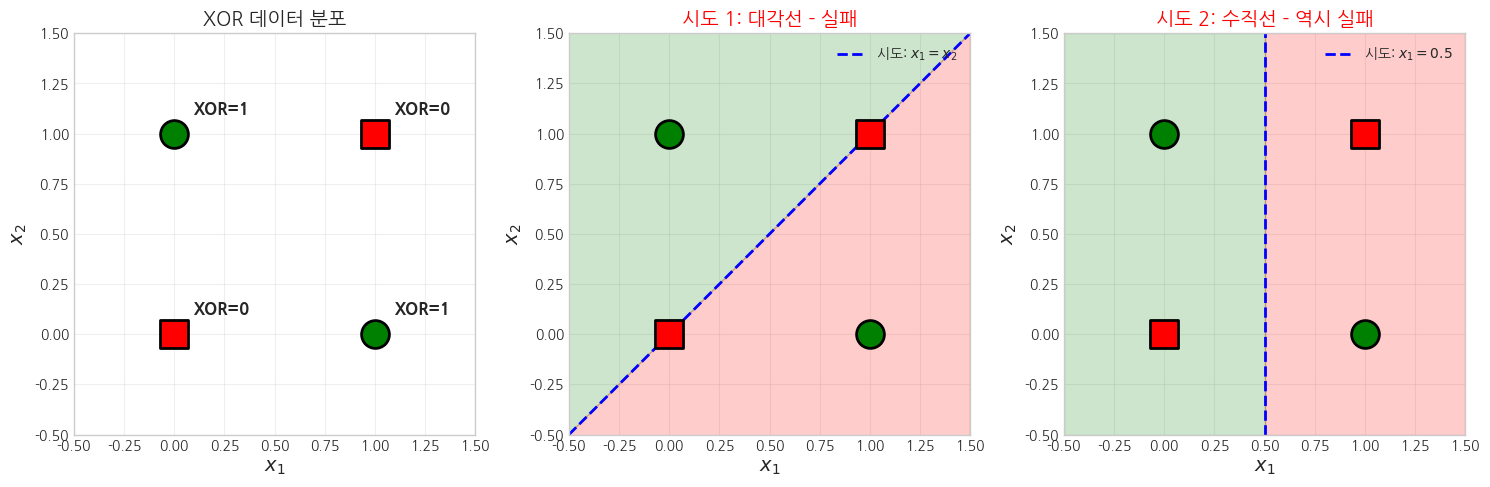


XOR 문제의 핵심:
- 출력 1인 점 (0,1)과 (1,0)은 대각선 방향
- 출력 0인 점 (0,0)과 (1,1)도 대각선 방향
- 어떤 직선을 그어도 완벽히 분리 불가능!
- 이것이 '선형 분리 불가능(Linearly Non-Separable)' 문제


In [7]:
def visualize_xor_problem():
    """
    XOR 문제가 왜 선형 분리 불가능한지 시각화
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # XOR 데이터
    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y_xor = np.array([0, 1, 1, 0])
    colors = ['red' if label == 0 else 'green' for label in y_xor]
    
    # 그래프 1: XOR 데이터 분포
    ax = axes[0]
    for i, (x, label) in enumerate(zip(X, y_xor)):
        marker = 'o' if label == 1 else 's'
        ax.scatter(x[0], x[1], c=colors[i], s=400, marker=marker,
                   edgecolor='black', linewidth=2, zorder=5)
        ax.annotate(f'XOR={label}', (x[0]+0.1, x[1]+0.1), fontsize=12, fontweight='bold')
    
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('$x_1$', fontsize=14)
    ax.set_ylabel('$x_2$', fontsize=14)
    ax.set_title('XOR 데이터 분포', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    # 그래프 2: 직선 시도 1 (y = x)
    ax = axes[1]
    for i, (x, label) in enumerate(zip(X, y_xor)):
        marker = 'o' if label == 1 else 's'
        ax.scatter(x[0], x[1], c=colors[i], s=400, marker=marker,
                   edgecolor='black', linewidth=2, zorder=5)
    
    x_line = np.linspace(-0.5, 1.5, 100)
    ax.plot(x_line, x_line, 'b--', linewidth=2, label='시도: $x_1 = x_2$')
    ax.fill_between(x_line, x_line, 2, alpha=0.2, color='green')
    ax.fill_between(x_line, -1, x_line, alpha=0.2, color='red')
    
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('$x_1$', fontsize=14)
    ax.set_ylabel('$x_2$', fontsize=14)
    ax.set_title('시도 1: 대각선 - 실패', fontsize=14, color='red')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    # 그래프 3: 직선 시도 2 (x = 0.5)
    ax = axes[2]
    for i, (x, label) in enumerate(zip(X, y_xor)):
        marker = 'o' if label == 1 else 's'
        ax.scatter(x[0], x[1], c=colors[i], s=400, marker=marker,
                   edgecolor='black', linewidth=2, zorder=5)
    
    ax.axvline(x=0.5, color='b', linestyle='--', linewidth=2, label='시도: $x_1 = 0.5$')
    ax.fill_betweenx([-0.5, 1.5], -0.5, 0.5, alpha=0.2, color='green')
    ax.fill_betweenx([-0.5, 1.5], 0.5, 1.5, alpha=0.2, color='red')
    
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('$x_1$', fontsize=14)
    ax.set_ylabel('$x_2$', fontsize=14)
    ax.set_title('시도 2: 수직선 - 역시 실패', fontsize=14, color='red')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "=" * 60)
    print("XOR 문제의 핵심:")
    print("=" * 60)
    print("- 출력 1인 점 (0,1)과 (1,0)은 대각선 방향")
    print("- 출력 0인 점 (0,0)과 (1,1)도 대각선 방향")
    print("- 어떤 직선을 그어도 완벽히 분리 불가능!")
    print("- 이것이 '선형 분리 불가능(Linearly Non-Separable)' 문제")

visualize_xor_problem()

### 3. 역사적 맥락: AI 겨울의 시작

**1969년, Marvin Minsky와 Seymour Papert**의 저서 "Perceptrons"에서 단일 퍼셉트론의 한계를 수학적으로 증명함.

> "퍼셉트론은 XOR과 같은 **선형 분리 불가능한 문제**를 풀 수 없다."

**파급 효과**:
- 신경망 연구에 대한 회의론 급증
- 연구 자금 대폭 삭감
- 약 15~20년간 **"AI 겨울"** (AI Winter) 시작

**해결책**: 층을 쌓자! (다층 퍼셉트론의 등장)

## 4: 다층 퍼셉트론(MLP)의 등장

### 4.1 핵심 아이디어: 중간 단계(은닉층) 추가

```mermaid
flowchart LR
    subgraph 단일_퍼셉트론
        A1[x1, x2] --> B1[뉴런] --> C1[y]
    end
    
    subgraph 다층_퍼셉트론_MLP
        A2[x1, x2] --> B2[은닉층] --> C2[출력층] --> D2[y]
    end
    
    단일_퍼셉트론 -.->|실패| XOR문제
    다층_퍼셉트론_MLP -.->|성공| XOR문제
```

### 4.2 XOR의 논리적 분해

XOR은 AND, OR, NAND의 조합으로 표현 가능:

$$\text{XOR}(x_1, x_2) = \text{AND}(\text{NAND}(x_1, x_2), \text{OR}(x_1, x_2))$$

| $x_1$ | $x_2$ | NAND | OR | AND(NAND, OR) |
|:---:|:---:|:---:|:---:|:---:|
| 0 | 0 | 1 | 0 | **0** |
| 0 | 1 | 1 | 1 | **1** |
| 1 | 0 | 1 | 1 | **1** |
| 1 | 1 | 0 | 1 | **0** |

In [9]:
def XOR_network(x1, x2, verbose=False):
    """
    XOR을 다층 퍼셉트론으로 구현
    
    구조:
        입력층: x1, x2
        은닉층: NAND(h1), OR(h2)
        출력층: AND
    
    수학적 표현:
        h1 = NAND(x1, x2)
        h2 = OR(x1, x2)
        y = AND(h1, h2)
    """
    # 은닉층 계산
    h1 = NAND_gate(x1, x2)  # 첫 번째 은닉 뉴런
    h2 = OR_gate(x1, x2)    # 두 번째 은닉 뉴런
    
    # 출력층 계산
    y = AND_gate(h1, h2)    # 출력 뉴런
    
    if verbose:
        print(f"입력: ({x1}, {x2})")
        print(f"은닉층: NAND={h1}, OR={h2}")
        print(f"출력: AND({h1}, {h2}) = {y}")
    
    return y

# XOR 네트워크 테스트
print("=" * 60)
print("XOR 다층 퍼셉트론 (MLP) 진리표")
print("=" * 60)
print(f"{'x1':^6} {'x2':^6} {'NAND(h1)':^10} {'OR(h2)':^10} {'XOR(출력)':^10}")
print("-" * 60)

for x1 in [0, 1]:
    for x2 in [0, 1]:
        h1 = NAND_gate(x1, x2)
        h2 = OR_gate(x1, x2)
        y = XOR_network(x1, x2)
        print(f"{x1:^6} {x2:^6} {h1:^10} {h2:^10} {y:^10}")

print("\n성공! 다층 퍼셉트론으로 XOR 문제 해결!")

XOR 다층 퍼셉트론 (MLP) 진리표
  x1     x2    NAND(h1)    OR(h2)    XOR(출력)  
------------------------------------------------------------
  0      0        1          0          0     
  0      1        1          1          1     
  1      0        1          1          1     
  1      1        0          1          0     

성공! 다층 퍼셉트론으로 XOR 문제 해결!


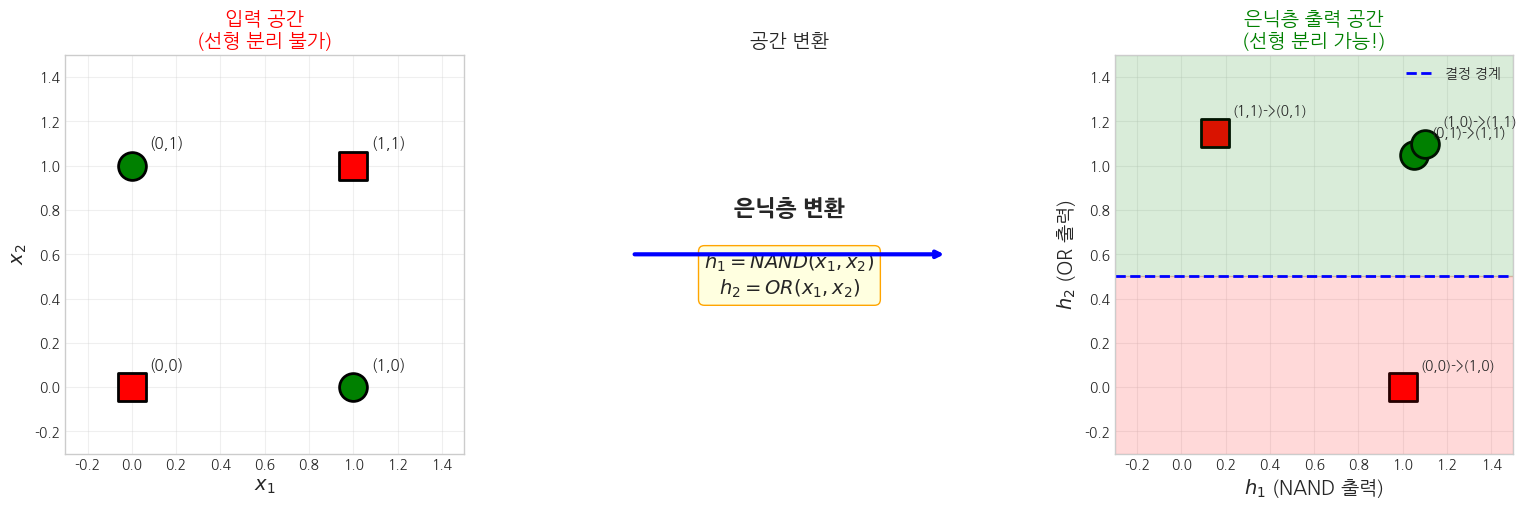


은닉층의 역할:
1. 원래 공간 (x1, x2)에서는 직선으로 분리 불가
2. 은닉층이 새로운 표현 (h1, h2)로 변환
3. 변환된 공간에서는 직선으로 분리 가능!

이것이 '특징 학습(Feature Learning)'의 시작


In [10]:
def visualize_space_transformation():
    """
    은닉층이 공간을 어떻게 변환하는지 시각화
    
    핵심 아이디어:
    - 원래 공간에서 선형 분리 불가능한 데이터를
    - 은닉층을 통해 새로운 공간으로 변환하면
    - 선형 분리 가능해짐!
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # 원래 입력
    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y_xor = np.array([0, 1, 1, 0])
    
    # 은닉층 출력 계산
    H = []
    for x1, x2 in X:
        h1 = NAND_gate(x1, x2)
        h2 = OR_gate(x1, x2)
        H.append([h1, h2])
    H = np.array(H)
    
    colors = ['red' if label == 0 else 'green' for label in y_xor]
    
    # 그래프 1: 입력 공간
    ax = axes[0]
    for i, (x, label) in enumerate(zip(X, y_xor)):
        marker = 'o' if label == 1 else 's'
        ax.scatter(x[0], x[1], c=colors[i], s=400, marker=marker,
                   edgecolor='black', linewidth=2)
        ax.annotate(f'({x[0]},{x[1]})', (x[0]+0.08, x[1]+0.08), fontsize=11)
    ax.set_xlabel('$x_1$', fontsize=14)
    ax.set_ylabel('$x_2$', fontsize=14)
    ax.set_title('입력 공간\n(선형 분리 불가)', fontsize=14, color='red')
    ax.set_xlim(-0.3, 1.5)
    ax.set_ylim(-0.3, 1.5)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    # 그래프 2: 변환 설명
    ax = axes[1]
    ax.text(0.5, 0.6, '은닉층 변환', fontsize=16, ha='center', fontweight='bold')
    ax.text(0.5, 0.4, '$h_1 = NAND(x_1, x_2)$\n$h_2 = OR(x_1, x_2)$', 
            fontsize=14, ha='center', family='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='orange'))
    ax.annotate('', xy=(0.85, 0.5), xytext=(0.15, 0.5),
                arrowprops=dict(arrowstyle='->', lw=3, color='blue'))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title('공간 변환', fontsize=14)
    
    # 그래프 3: 은닉층 출력 공간
    ax = axes[2]
    for i, (h, label) in enumerate(zip(H, y_xor)):
        marker = 'o' if label == 1 else 's'
        # 약간의 오프셋 추가 (겹치는 점 구분)
        offset = 0.05 * i
        ax.scatter(h[0]+offset, h[1]+offset, c=colors[i], s=400, marker=marker,
                   edgecolor='black', linewidth=2)
        ax.annotate(f'({X[i,0]},{X[i,1]})->({h[0]},{h[1]})', 
                    (h[0]+0.08+offset, h[1]+0.08+offset), fontsize=10)
    
    # 결정 경계 추가
    h1_line = np.linspace(-0.3, 1.5, 100)
    h2_line = 0.5 * np.ones_like(h1_line)
    ax.plot(h1_line, h2_line, 'b--', linewidth=2, label='결정 경계')
    ax.fill_between(h1_line, h2_line, 1.5, alpha=0.15, color='green')
    ax.fill_between(h1_line, -0.3, h2_line, alpha=0.15, color='red')
    
    ax.set_xlabel('$h_1$ (NAND 출력)', fontsize=14)
    ax.set_ylabel('$h_2$ (OR 출력)', fontsize=14)
    ax.set_title('은닉층 출력 공간\n(선형 분리 가능!)', fontsize=14, color='green')
    ax.set_xlim(-0.3, 1.5)
    ax.set_ylim(-0.3, 1.5)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')
    ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "=" * 60)
    print("은닉층의 역할:")
    print("=" * 60)
    print("1. 원래 공간 (x1, x2)에서는 직선으로 분리 불가")
    print("2. 은닉층이 새로운 표현 (h1, h2)로 변환")
    print("3. 변환된 공간에서는 직선으로 분리 가능!")
    print("\n이것이 '특징 학습(Feature Learning)'의 시작")

visualize_space_transformation()

---

## 5: 순전파와 역전파

### 5.1 순전파 (Forward Propagation)

**정의**: 입력에서 출력 방향으로 데이터가 흐르며 계산되는 과정

```mermaid
flowchart LR
    A[입력 x] -->|W1, b1| B[은닉층 h]
    B -->|W2, b2| C[출력 y]
    C --> D[손실 L]
    
    style A fill:#e3f2fd
    style B fill:#e8f5e9
    style C fill:#fff3e0
    style D fill:#ffebee
```

#### 2층 MLP의 순전파 수식

**Step 1: 은닉층 계산**

$$z^{(1)} = W^{(1)} x + b^{(1)}$$
$$h = f(z^{(1)})$$

**Step 2: 출력층 계산**

$$z^{(2)} = W^{(2)} h + b^{(2)}$$
$$\hat{y} = f(z^{(2)})$$

**Step 3: 손실 계산 (MSE)**

$$L = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

In [11]:
class SimpleMLP:
    """
    순전파와 역전파를 모두 구현한 간단한 다층 퍼셉트론
    
    구조:
        입력층 (input_size) -> 은닉층 (hidden_size) -> 출력층 (output_size)
    
    학습 알고리즘:
        1. 순전파: 예측값 계산
        2. 손실 계산: 예측값과 실제값의 차이
        3. 역전파: 기울기 계산 (연쇄 법칙)
        4. 가중치 업데이트: 경사 하강법
    """
    
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.5):
        """
        가중치 초기화
        
        Xavier 초기화 사용: 분산 = 2 / (fan_in + fan_out)
        """
        np.random.seed(42)  # 재현성을 위한 시드 고정
        
        # 가중치 초기화 (작은 랜덤 값)
        self.W1 = np.random.randn(input_size, hidden_size) * 0.5
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.5
        self.b2 = np.zeros((1, output_size))
        
        self.lr = learning_rate
        self.losses = []
    
    def sigmoid(self, z):
        """시그모이드 활성화 함수"""
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
    
    def sigmoid_derivative(self, z):
        """
        시그모이드 미분
        
        수식: sigma'(z) = sigma(z) * (1 - sigma(z))
        """
        s = self.sigmoid(z)
        return s * (1 - s)
    
    def forward(self, X):
        """
        순전파 계산
        
        X: 입력 데이터 (samples, features)
        """
        # Step 1: 은닉층
        self.z1 = X @ self.W1 + self.b1  # 가중합
        self.h = self.sigmoid(self.z1)    # 활성화
        
        # Step 2: 출력층
        self.z2 = self.h @ self.W2 + self.b2  # 가중합
        self.y_pred = self.sigmoid(self.z2)    # 활성화 (출력)
        
        return self.y_pred
    
    def compute_loss(self, y_true):
        """평균 제곱 오차 (MSE) 계산"""
        return np.mean((y_true - self.y_pred) ** 2)
    
    def backward(self, X, y_true):
        """
        역전파: 기울기 계산 및 가중치 업데이트
        
        연쇄 법칙 (Chain Rule):
            dL/dW2 = dL/dy * dy/dz2 * dz2/dW2
            dL/dW1 = dL/dy * dy/dz2 * dz2/dh * dh/dz1 * dz1/dW1
        """
        m = X.shape[0]  # 샘플 수
        
        # Step 1: 출력층 오차 (delta2)
        # dL/dz2 = (y_pred - y_true) * sigmoid'(z2)
        delta2 = (self.y_pred - y_true) * self.sigmoid_derivative(self.z2)
        
        # Step 2: 출력층 가중치 기울기
        dW2 = (self.h.T @ delta2) / m
        db2 = np.sum(delta2, axis=0, keepdims=True) / m
        
        # Step 3: 은닉층 오차 (delta1)
        # 오차를 역방향으로 전파
        delta1 = (delta2 @ self.W2.T) * self.sigmoid_derivative(self.z1)
        
        # Step 4: 은닉층 가중치 기울기
        dW1 = (X.T @ delta1) / m
        db1 = np.sum(delta1, axis=0, keepdims=True) / m
        
        # Step 5: 가중치 업데이트 (경사 하강법)
        # w_new = w_old - learning_rate * gradient
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
    
    def train(self, X, y_true, epochs=1000, print_every=200):
        """
        학습 루프
        
        1 에포크 = 전체 데이터에 대한 1회 순전파 + 역전파
        """
        self.losses = []
        
        for epoch in range(epochs):
            # 순전파
            self.forward(X)
            
            # 손실 계산
            loss = self.compute_loss(y_true)
            self.losses.append(loss)
            
            # 역전파
            self.backward(X, y_true)
            
            if epoch % print_every == 0:
                print(f"Epoch {epoch:5d}: Loss = {loss:.6f}")
        
        return self.losses
    
    def predict(self, X):
        """예측 (임계값 0.5 기준)"""
        return (self.forward(X) > 0.5).astype(int)

### 5.2 역전파 (Backpropagation)

**정의**: 손실을 출력에서 입력 방향으로 전파하여 각 가중치의 기울기를 계산하는 과정

```mermaid
flowchart RL
    D[손실 L] -->|dL/dy| C[출력 y]
    C -->|dL/dW2| B[은닉층 h]
    B -->|dL/dW1| A[입력 x]
    
    style D fill:#ffebee
    style C fill:#fff3e0
    style B fill:#e8f5e9
    style A fill:#e3f2fd
```

#### 핵심: 연쇄 법칙 (Chain Rule)

합성 함수의 미분:

$$\frac{d}{dx} f(g(x)) = f'(g(x)) \cdot g'(x)$$

신경망에서:

$$\frac{\partial L}{\partial w_1} = \frac{\partial L}{\partial y} \cdot \frac{\partial y}{\partial h} \cdot \frac{\partial h}{\partial w_1}$$

**비유**: 도미노 효과
- $w_1$이 바뀌면 $h$가 바뀌고, $y$가 바뀌고, $L$이 바뀜
- 각 단계의 변화량을 곱해서 전체 영향 계산

In [12]:
# XOR 학습 실행
print("=" * 60)
print("XOR 문제 학습 (순전파 + 역전파)")
print("=" * 60)

# XOR 데이터
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

# MLP 생성 및 학습
mlp = SimpleMLP(input_size=2, hidden_size=4, output_size=1, learning_rate=2.0)

print("\n학습 전 예측:")
y_pred_before = mlp.forward(X)
for i in range(4):
    print(f"XOR({X[i,0]}, {X[i,1]}) = {y_pred_before[i,0]:.4f} (정답: {y[i,0]})")

print("\n" + "-" * 40)
print("학습 시작...")
print("-" * 40)

losses = mlp.train(X, y, epochs=2000, print_every=400)

print("\n" + "-" * 40)
print("학습 후 예측:")
print("-" * 40)
y_pred_after = mlp.forward(X)
for i in range(4):
    pred = y_pred_after[i, 0]
    pred_class = 1 if pred > 0.5 else 0
    status = "정답" if pred_class == y[i, 0] else "오답"
    print(f"XOR({X[i,0]}, {X[i,1]}) = {pred:.4f} -> {pred_class} ({status})")

XOR 문제 학습 (순전파 + 역전파)

학습 전 예측:
XOR(0, 0) = 0.4467 (정답: 0)
XOR(0, 1) = 0.4303 (정답: 1)
XOR(1, 0) = 0.4270 (정답: 1)
XOR(1, 1) = 0.4126 (정답: 0)

----------------------------------------
학습 시작...
----------------------------------------
Epoch     0: Loss = 0.255675
Epoch   400: Loss = 0.249831
Epoch   800: Loss = 0.243961
Epoch  1200: Loss = 0.125944
Epoch  1600: Loss = 0.014727

----------------------------------------
학습 후 예측:
----------------------------------------
XOR(0, 0) = 0.0765 -> 0 (정답)
XOR(0, 1) = 0.9310 -> 1 (정답)
XOR(1, 0) = 0.9308 -> 1 (정답)
XOR(1, 1) = 0.0737 -> 0 (정답)


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


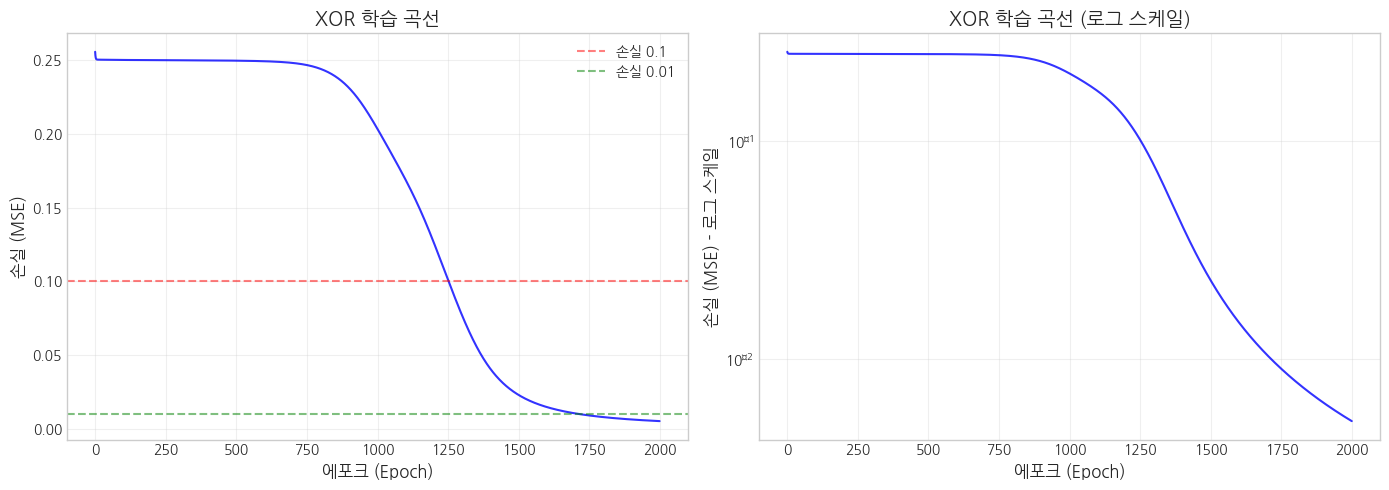


학습 결과 요약:
- 초기 손실: 0.255675
- 최종 손실: 0.005219
- 개선율: 97.96%


In [13]:
# 학습 곡선 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 그래프 1: 손실 변화 (일반 스케일)
ax = axes[0]
ax.plot(losses, 'b-', linewidth=1.5, alpha=0.8)
ax.set_xlabel('에포크 (Epoch)', fontsize=12)
ax.set_ylabel('손실 (MSE)', fontsize=12)
ax.set_title('XOR 학습 곡선', fontsize=14)
ax.grid(True, alpha=0.3)

# 주요 구간 표시
ax.axhline(y=0.1, color='r', linestyle='--', alpha=0.5, label='손실 0.1')
ax.axhline(y=0.01, color='g', linestyle='--', alpha=0.5, label='손실 0.01')
ax.legend()

# 그래프 2: 손실 변화 (로그 스케일)
ax = axes[1]
ax.plot(losses, 'b-', linewidth=1.5, alpha=0.8)
ax.set_xlabel('에포크 (Epoch)', fontsize=12)
ax.set_ylabel('손실 (MSE) - 로그 스케일', fontsize=12)
ax.set_title('XOR 학습 곡선 (로그 스케일)', fontsize=14)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n학습 결과 요약:")
print(f"- 초기 손실: {losses[0]:.6f}")
print(f"- 최종 손실: {losses[-1]:.6f}")
print(f"- 개선율: {(1 - losses[-1]/losses[0])*100:.2f}%")

## 6 실제 제조 데이터 적용 - WM-811K 웨이퍼 결함 분류

**WM-811K 데이터셋**은 반도체 제조 공정에서 수집된 실제 웨이퍼 맵(Wafer Bin Map) 데이터임.

| 항목 | 내용 |
|:---:|:---|
| 데이터 수 | 811,457개 웨이퍼 맵 |
| 결함 유형 | Center, Donut, Edge-Loc, Edge-Ring, Loc, Random, Scratch, Near-full, none |
| 출처 | 실제 반도체 제조 현장 |
| 용도 | 웨이퍼 결함 패턴 자동 분류 |

**제조 현장에서의 활용**:
- 숙련된 공정 엔지니어가 수동으로 분류하던 작업을 자동화
- 결함 패턴 분석을 통해 공정 문제 원인 파악
- 수율 향상 및 비용 절감

In [14]:
# 간단한 시뮬레이션 데이터로 MLP 동작 원리 확인
# (실제 WM-811K 데이터는 이미지 형태이므로, 
#  여기서는 센서 데이터 형태로 시뮬레이션)

print("=" * 60)
print("제조 공정 품질 예측 시뮬레이션")
print("=" * 60)

# 시뮬레이션: 웨이퍼 결함 관련 특성
# 특성: [중심부 결함 밀도, 가장자리 결함 밀도, 전체 결함 수, 패턴 불규칙도]
np.random.seed(42)

# 정상 웨이퍼 (양품)
n_normal = 100
X_normal = np.random.randn(n_normal, 4) * 0.3 + np.array([0.2, 0.2, 0.1, 0.1])
y_normal = np.zeros((n_normal, 1))

# 결함 웨이퍼 (불량)
n_defect = 100
X_defect = np.random.randn(n_defect, 4) * 0.4 + np.array([0.7, 0.8, 0.9, 0.6])
y_defect = np.ones((n_defect, 1))

# 데이터 결합
X_wafer = np.vstack([X_normal, X_defect])
y_wafer = np.vstack([y_normal, y_defect])

# 데이터 셔플
shuffle_idx = np.random.permutation(len(X_wafer))
X_wafer = X_wafer[shuffle_idx]
y_wafer = y_wafer[shuffle_idx]

# 데이터 정규화 (0-1 범위)
X_wafer = (X_wafer - X_wafer.min(axis=0)) / (X_wafer.max(axis=0) - X_wafer.min(axis=0) + 1e-8)

# 훈련/테스트 분리
train_size = 160
X_train, X_test = X_wafer[:train_size], X_wafer[train_size:]
y_train, y_test = y_wafer[:train_size], y_wafer[train_size:]

print(f"\n데이터셋 구성:")
print(f"- 전체 샘플: {len(X_wafer)}개")
print(f"- 훈련 샘플: {len(X_train)}개")
print(f"- 테스트 샘플: {len(X_test)}개")
print(f"- 특성 수: {X_wafer.shape[1]}개")
print(f"  (중심부 결함 밀도, 가장자리 결함 밀도, 전체 결함 수, 패턴 불규칙도)")

제조 공정 품질 예측 시뮬레이션

데이터셋 구성:
- 전체 샘플: 200개
- 훈련 샘플: 160개
- 테스트 샘플: 40개
- 특성 수: 4개
  (중심부 결함 밀도, 가장자리 결함 밀도, 전체 결함 수, 패턴 불규칙도)


In [15]:
# 웨이퍼 품질 예측 MLP 학습
print("\n" + "=" * 60)
print("MLP 모델 학습")
print("=" * 60)

# 모델 생성
wafer_mlp = SimpleMLP(input_size=4, hidden_size=8, output_size=1, learning_rate=1.0)

# 학습
losses = wafer_mlp.train(X_train, y_train, epochs=1000, print_every=200)

# 테스트 평가
y_pred_test = wafer_mlp.predict(X_test)
accuracy = np.mean(y_pred_test == y_test) * 100

print(f"\n테스트 정확도: {accuracy:.2f}%")


MLP 모델 학습
Epoch     0: Loss = 0.282316
Epoch   200: Loss = 0.170101
Epoch   400: Loss = 0.093346
Epoch   600: Loss = 0.063608
Epoch   800: Loss = 0.051600

테스트 정확도: 92.50%


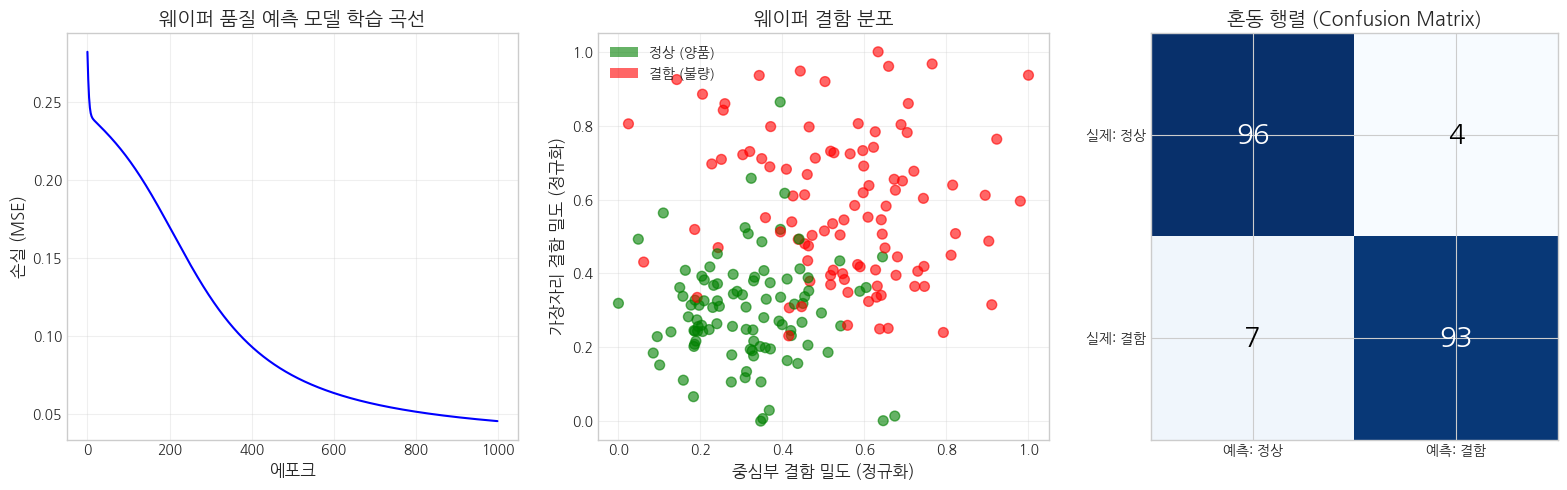


성능 지표:
----------------------------------------
정확도 (Accuracy): 94.50%
정밀도 (Precision): 95.88%
재현율 (Recall): 93.00%
F1 점수: 94.42%


In [16]:
# 결과 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 그래프 1: 학습 곡선
ax = axes[0]
ax.plot(losses, 'b-', linewidth=1.5)
ax.set_xlabel('에포크', fontsize=12)
ax.set_ylabel('손실 (MSE)', fontsize=12)
ax.set_title('웨이퍼 품질 예측 모델 학습 곡선', fontsize=14)
ax.grid(True, alpha=0.3)

# 그래프 2: 특성 분포 (중심부 vs 가장자리 결함 밀도)
ax = axes[1]
colors = ['green' if y == 0 else 'red' for y in y_wafer.flatten()]
ax.scatter(X_wafer[:, 0], X_wafer[:, 1], c=colors, alpha=0.6, s=50)
ax.set_xlabel('중심부 결함 밀도 (정규화)', fontsize=12)
ax.set_ylabel('가장자리 결함 밀도 (정규화)', fontsize=12)
ax.set_title('웨이퍼 결함 분포', fontsize=14)
ax.grid(True, alpha=0.3)

# 범례 추가
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', alpha=0.6, label='정상 (양품)'),
                   Patch(facecolor='red', alpha=0.6, label='결함 (불량)')]
ax.legend(handles=legend_elements, loc='upper left')

# 그래프 3: 혼동 행렬 (Confusion Matrix)
ax = axes[2]

# 혼동 행렬 계산
y_pred_all = wafer_mlp.predict(X_wafer)
tp = np.sum((y_pred_all == 1) & (y_wafer == 1))
tn = np.sum((y_pred_all == 0) & (y_wafer == 0))
fp = np.sum((y_pred_all == 1) & (y_wafer == 0))
fn = np.sum((y_pred_all == 0) & (y_wafer == 1))

cm = np.array([[tn, fp], [fn, tp]])
im = ax.imshow(cm, cmap='Blues')

# 값 표시
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, f'{cm[i, j]}', ha='center', va='center', 
                       fontsize=20, color='white' if cm[i, j] > 50 else 'black')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['예측: 정상', '예측: 결함'])
ax.set_yticklabels(['실제: 정상', '실제: 결함'])
ax.set_title('혼동 행렬 (Confusion Matrix)', fontsize=14)

plt.tight_layout()
plt.show()

# 성능 지표 계산
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print("\n성능 지표:")
print("-" * 40)
print(f"정확도 (Accuracy): {(tp+tn)/(tp+tn+fp+fn)*100:.2f}%")
print(f"정밀도 (Precision): {precision*100:.2f}%")
print(f"재현율 (Recall): {recall*100:.2f}%")
print(f"F1 점수: {f1*100:.2f}%")

---

## 핵심 정리

### 핵심 수식 정리

| 개념 | 수식 |
|:---:|:---|
| 퍼셉트론 | $y = f(\sum w_i x_i + b)$ |
| 시그모이드 | $\sigma(z) = \frac{1}{1+e^{-z}}$ |
| MSE 손실 | $L = \frac{1}{n}\sum(y - \hat{y})^2$ |
| 경사 하강법 | $w_{new} = w_{old} - \eta \frac{\partial L}{\partial w}$ |

### 체크리스트

- [ ] 생물학적 뉴런과 인공 뉴런의 대응 관계 이해
- [ ] 퍼셉트론으로 AND, OR 게이트 구현 가능
- [ ] XOR 문제가 왜 단일 퍼셉트론으로 불가능한지 설명 가능
- [ ] MLP의 은닉층이 공간을 변환하는 역할 이해
- [ ] 순전파의 계산 과정 이해
- [ ] 역전파의 개념과 연쇄 법칙 이해
- [ ] 경사 하강법으로 가중치 업데이트 이해